Оцінювання наявності даної роботи буде враховувати як наявність самих візуалізацій (вони можуть незначно відрізнятися від прикладів, але повинні змістовно відображати суть задачі) та опис отриманих вами результатів. При наявності ЛИШЕ візуалізацій без роз'яснень, завдання не буде зараховане за наявне.

Під час виконання вам дозволено користуватися будь-якими зручними для вас Python бібліотеками для візуалізації.

# I. Receiving Data.

In [ ]:
import pandas as pd

1. (2б) Для виконання цієї лабораторної роботи Вам необхідно скористатися вибіркою titanic ([train.csv](https://www.kaggle.com/c/titanic/data?select=train.csv)). Зчитайте його та збережіть його у змінну, щоб у подальшому її використати для візуалізацій. Виведіть інформацію про кожну колонку, її індекс, тип та кількість непропущених значень та перші кілька рядків датафрейму.


In [31]:
import pandas as pd
# Load the Titanic dataset
file_path = '/content/sample_data/train.csv'
df = pd.read_csv(file_path)

def display_first_rows(df, n=5):
    """
    Displays the first few rows of the Titanic dataset.

    Args:
        df (pd.DataFrame): The Titanic dataset.
        n (int): The number of rows to display. Default is 5.

    Returns:
        None: This function prints the first few rows of the DataFrame.
    """
    print("First few rows of the Titanic dataset:")
    print(df.head(n))

display_first_rows(df)



First few rows of the Titanic dataset:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0        

In [32]:
def display_column_info(df):
    """
    Displays information about each column in the Titanic dataset.

    Args:
        df (pd.DataFrame): The Titanic dataset.

    Returns:
        None: This function prints information about the columns, including
              their index, data type, and count of non-null values.
    """
    print("\nInformation about dataset:")
    print(df.info())
display_column_info(df)




Information about dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


# IІ. Data Visualization.

2. (10б) Створіть pie chart, який би показував співвідношення виживших до загиблих.

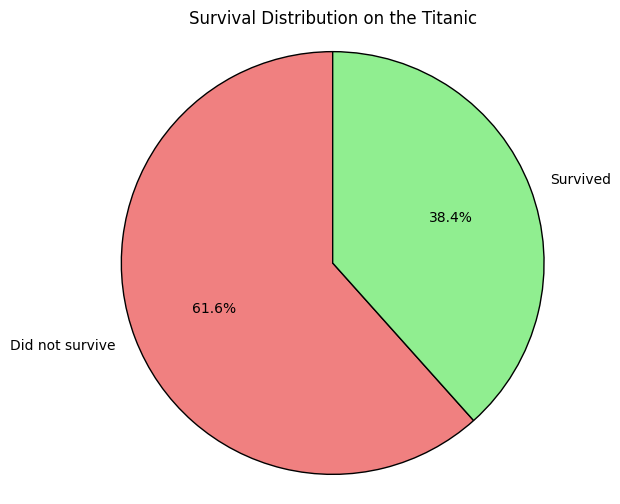

In [8]:
import matplotlib.pyplot as plt

def plot_survival_pie_chart(df):
    """
    Plots a pie chart showing the ratio of survivors to non-survivors.

    Args:
        df (pd.DataFrame): The Titanic dataset with a 'Survived' column
                           where 1 indicates survived and 0 indicates not survived.

    Returns:
        None: Displays the pie chart.
    """
    # Count the number of survivors and non-survivors
    survival_counts = df['Survived'].value_counts()
    labels = ['Did not survive', 'Survived']
    colors = ['lightcoral', 'lightgreen']

    # Plotting the pie chart
    plt.figure(figsize=(6, 6))
    plt.pie(
        survival_counts,
        labels=labels,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors,
        wedgeprops={'edgecolor': 'black'}
    )
    plt.title('Survival Distribution on the Titanic')
    plt.axis('equal')  # Equal aspect ratio ensures pie is drawn as a circle.
    plt.show()

# Call the function
plot_survival_pie_chart(df)


Отримана секторна (або кругова) діаграма ілюструє наглядно відсоткове співвідношення вишивших та загиблих з усіх 100% . Бачимо, з отриманого аналізу, що загиблих було більше половини, проте разом з тим різницю важко назвати разючою - більше ніж чверть діаграми займають виживші (38,4%)

3. (20б) Створіть bar chart, який би показував співвідношення загиблих до виживших для кожної статі. Для groupby використовуйте атрибут as_index=False.


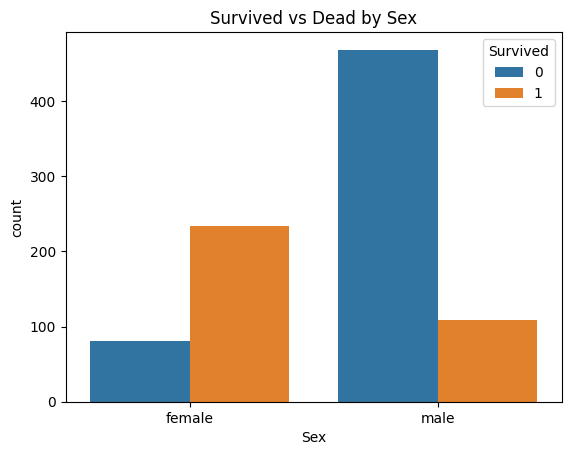

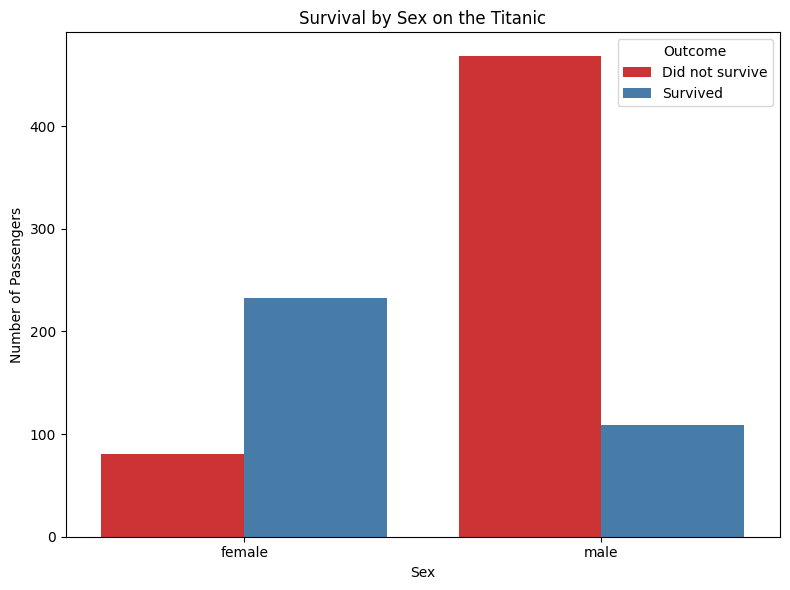

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_survival_by_sex(df):
    """
    Plots a bar chart comparing the number of survivors and non-survivors by sex.

    Args:
        df (pd.DataFrame): The Titanic dataset containing 'Survived' and 'Sex' columns.

    Returns:
        None: Displays the bar chart.
    """
    # Group by 'Sex' and 'Survived' with as_index=False
    survival_by_sex = df.groupby(['Sex', 'Survived'], as_index=False).size()

    # Replace 0 and 1 with descriptive labels for 'Survived'
    survival_by_sex['Survived'] = survival_by_sex['Survived'].map({0: 'Did not survive', 1: 'Survived'})

    # Plotting
    plt.figure(figsize=(8, 6))
    sns.barplot(data=survival_by_sex, x='Sex', y='size', hue='Survived', palette='Set1')

    plt.title('Survival by Sex on the Titanic')
    plt.xlabel('Sex')
    plt.ylabel('Number of Passengers')
    plt.legend(title='Outcome')
    plt.tight_layout()
    plt.show()

# Call the function
plot_survival_by_sex(df)


Ця стовпчикова діаграма показує розподіл "смертності" за статтю - кількість пасажирів, що вижили та загинули серед жінок і чоловіків. Як бачимо, найбільшою смертність була саме серед осіб чоловічої статі. При чому, кількість вишивших серед чоловіків та тих, хто загинув серед жінок майже однакова. З цієї ж діаграми також можна зрозуміти, що загальна кількість чоловіків також була більшою

4. (20б) Відобразіть кількість пропущених значень в датасеті по кожній із змінних.

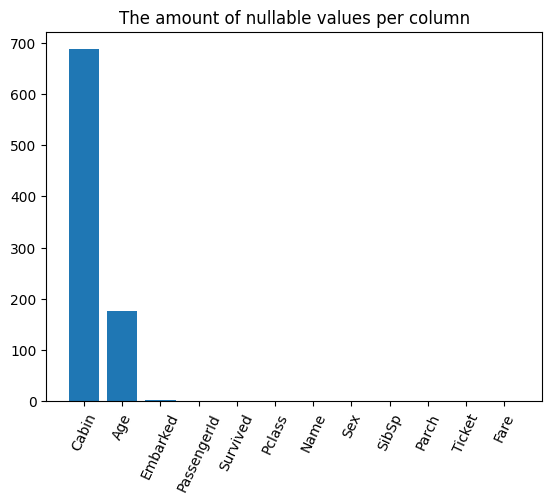

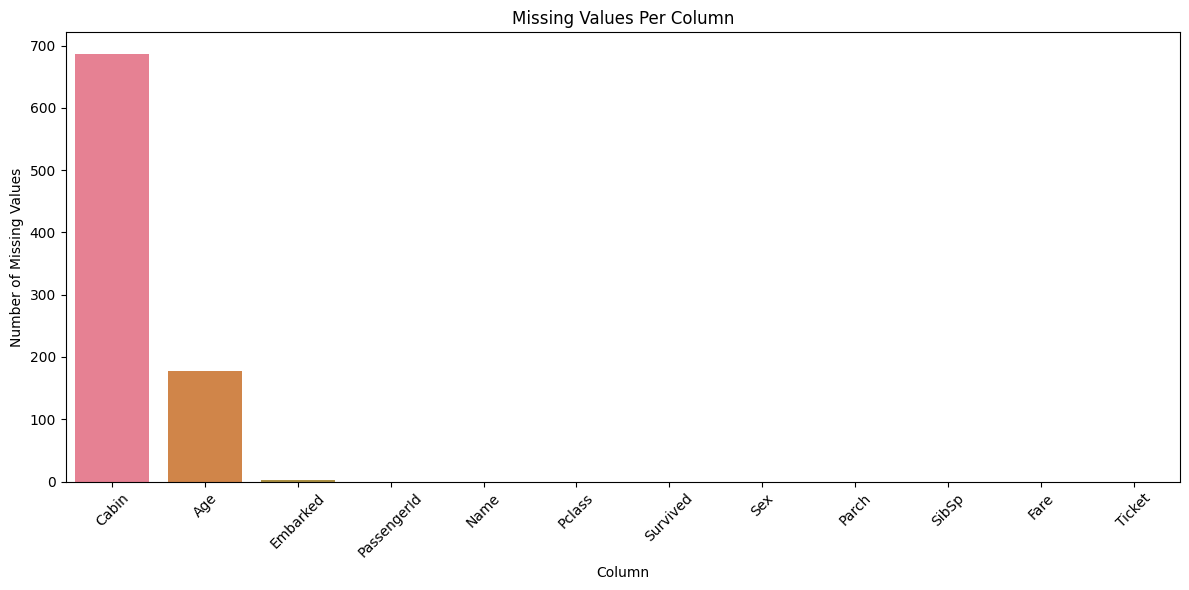

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_all_missing_values(df):
    """
    Plots a bar chart showing the number of missing values for each column in the dataset.

    Args:
        df (pd.DataFrame): The dataset to visualize missing values for.

    Returns:
        None: Displays the bar chart.
    """
    missing_values = df.isnull().sum()
    missing_values = missing_values.sort_values(ascending=False)

    data = pd.DataFrame({
        'Column': missing_values.index,
        'Missing': missing_values.values
    })

    plt.figure(figsize=(12, 6))
    sns.barplot(data=data, x='Column', y='Missing', hue='Column', legend=False)
    plt.title("Missing Values Per Column")
    plt.ylabel("Number of Missing Values")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Call the function
plot_all_missing_values(df)


На даній стовпчиковій діаграмі ми аналізуємо вже не стільки показники вибірки, як саму таблицю і дані в ній ( а саме пропущені, нульові дані). З зображення видно, що найбільше пропусків міститься в стовпчику з номером кабіни (кімнати), втрачені дані також є щодо віку та час/дата відправки. Робимо висновок, що табличні дані були досить вдало збережені, адже інші стовпчики подібних втрат не мають

5. (10б) Побудуйте наступний графік, дайте йому назву та опишіть, що власне на них відображається.

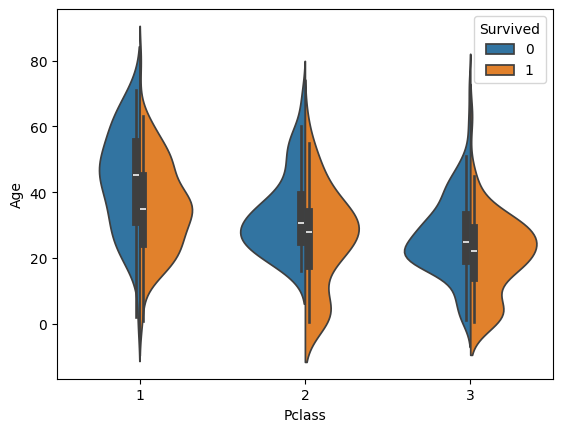

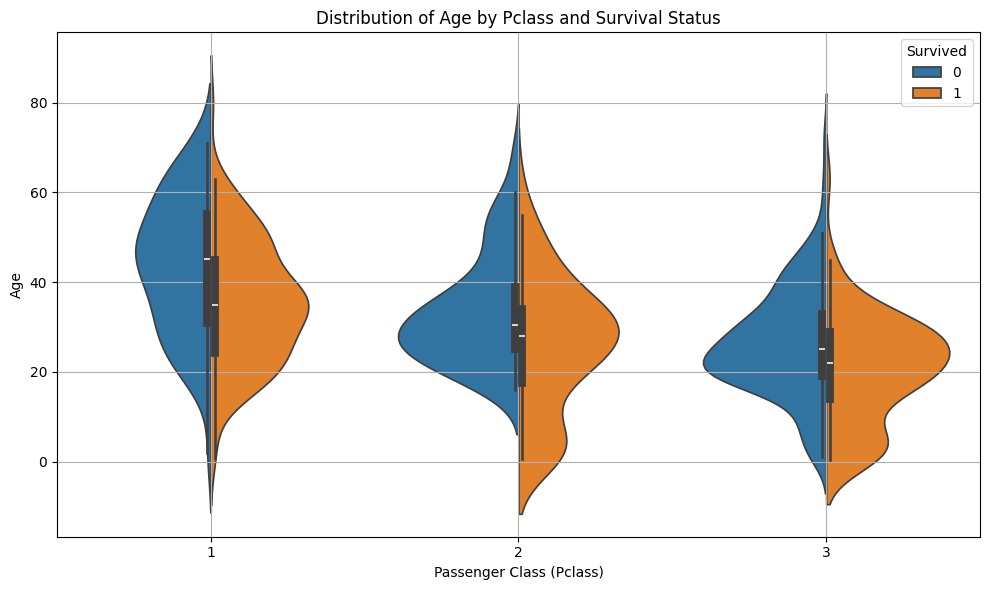

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_violin_age_vs_pclass(df):
    """
    Creates a violin plot to show the distribution of Age across Pclass,
    separated by survival status.

    Args:
        df (pd.DataFrame): The Titanic dataset.

    Returns:
        None: Displays the violin plot.
    """
    plt.figure(figsize=(10, 6))
    sns.violinplot(
        data=df,
        x='Pclass',
        y='Age',
        hue='Survived',
        split=True
    )
    plt.title('Distribution of Age by Pclass and Survival Status')
    plt.xlabel('Passenger Class (Pclass)')
    plt.ylabel('Age')
    plt.legend(title='Survived')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Call the function
plot_violin_age_vs_pclass(df)


Незвичайний графік - скрипкова діаграма, а точніше діаграми, які відображають залежність класу пасажирів, від переважаючої вікової групи і її виживання - чим далі "тіло" графіка відходить від основної прямої - тим більше людей належать певному віку. З поданого графіку можемо зробити досить багато висновків, проте я б виділила такій основні - в другому та третьому класі переважали люди вікової групи 20-40 років, ця ж група і зазнала найбільших втрат. В першому класі переважала група 40-60, але найбільше загиблих було у віці 20-40

6. (13б) Побудуйте графік розподілу частот по віку пасажирів.


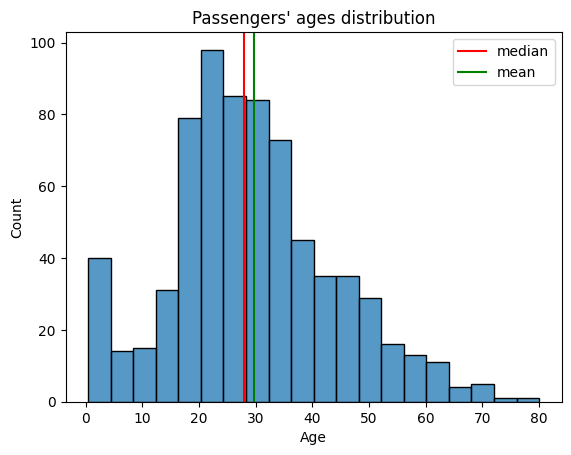

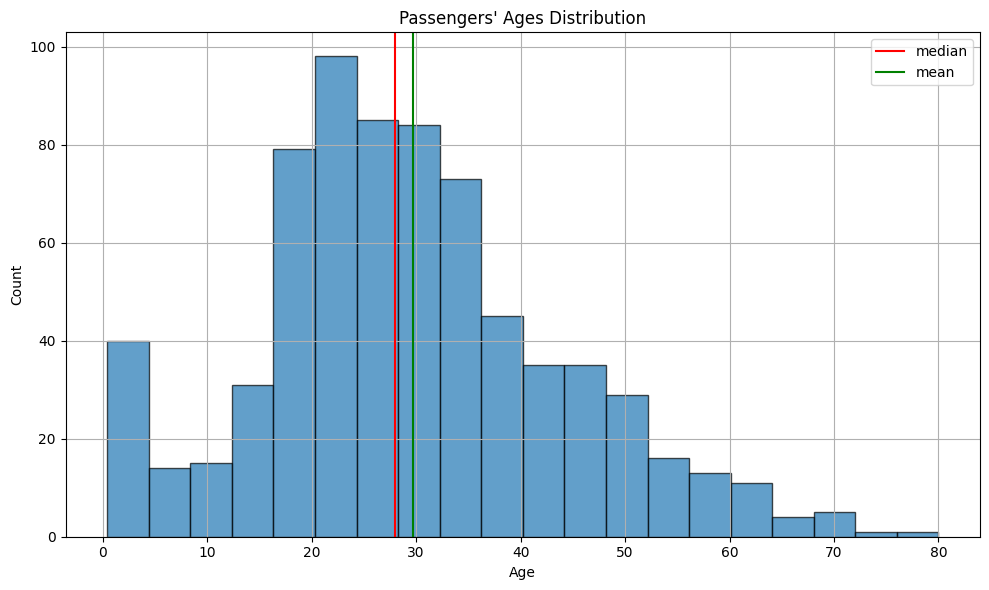

In [23]:
import matplotlib.pyplot as plt

def plot_age_distribution(df):
    """
    Plots the distribution of passengers' ages from the Titanic dataset,
    showing both the mean and median as vertical lines.

    Args:
        df (pd.DataFrame): The Titanic dataset containing an 'Age' column.

    Returns:
        None: Displays the histogram plot with mean and median markers.
    """
    plt.figure(figsize=(10, 6))

    # Create histogram
    plt.hist(df['Age'].dropna(), bins=20, edgecolor='black', alpha=0.7)

    # Plot median and mean lines
    plt.axvline(df['Age'].median(), color='red', label='median')
    plt.axvline(df['Age'].mean(), color='green', label='mean')

    # Titles and labels
    plt.title("Passengers' Ages Distribution")
    plt.xlabel('Age')
    plt.ylabel('Count')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Виклик функції
plot_age_distribution(df)


Стовпчата діаграма показує, як же у якій віковій категорії була найбільша кількість пасажирів - і як бачимо - віком 20-25 років. Також тут зображено стовпчату діаграму та середнє значення нашої вибірки - вони лежать в межах 29-30 років

7. (25б) Поставте бізнес-питання до даних. Дайте на нього відповідь за допомогою візуалізацій. Прокоментуйте отриману відповідь.

Чи впливала на шанс вижити вартість квитка (Fare)?

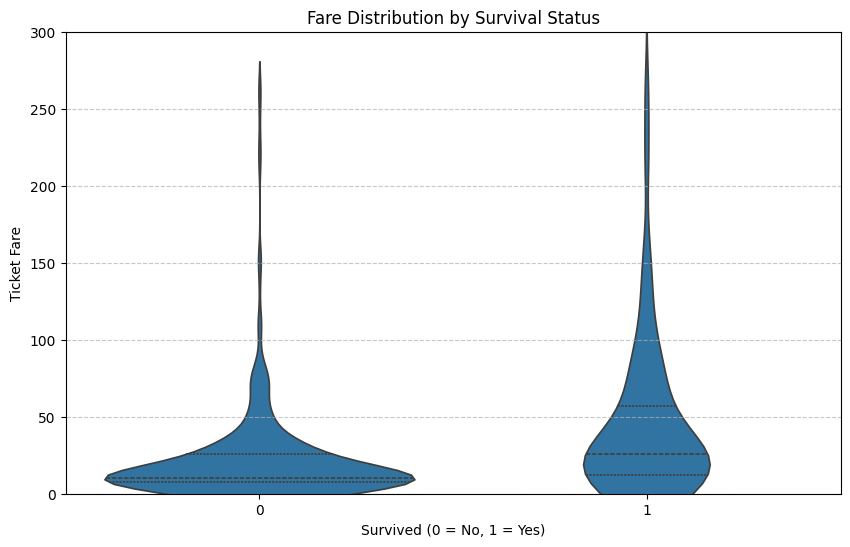

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_fare_vs_survival_violin(df):
    """
    Plots a violin plot to visualize the distribution of ticket fares
    for survivors and non-survivors on the Titanic.

    Args:
        df (pd.DataFrame): Titanic dataset containing 'Fare' and 'Survived' columns.

    Returns:
        None: Displays a violin plot for better comparison.
    """
    plt.figure(figsize=(10, 6))
    sns.violinplot(data=df, x='Survived', y='Fare', legend = False, inner='quartile')
    plt.title('Fare Distribution by Survival Status')
    plt.xlabel('Survived (0 = No, 1 = Yes)')
    plt.ylabel('Ticket Fare')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.ylim(0, 300)  # обмежимо осі, бо є екстремальні значення
    plt.show()

# Виклик функції
plot_fare_vs_survival_violin(df)


Діаграма відповідає на питання, як же вплинула ціна квитка на шанс виживання. І за нею чітко видно, що все ж власники дорожчих квитків краще виживали. Так, ми бачимо, що серед дешевих квитків є багато виживших, проте ще більше жертв. Робимо висновок, що така похибка відбувається через те, що саме дешевших квитків було найбільше.
Недоліком цієї діаграми є відсутність вказаної кількості людей, проте на мою думку, додавання цього фактору не дозволило б нас її вдало оптимізувати

# Вітаю! Ви велика(ий) молодець, що впоралась(вся). Похваліть себе та побалуйте чимось приємним. Я Вами пишаюся.

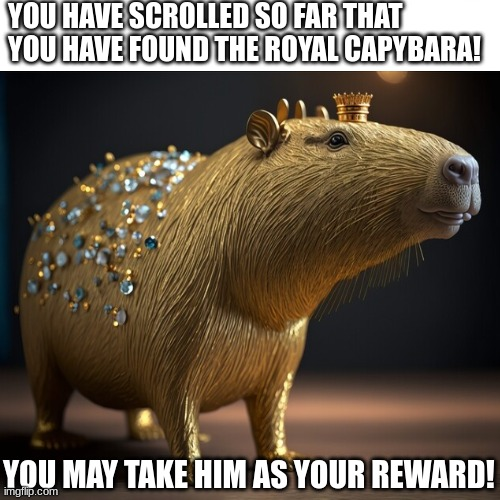